In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import os
os.makedirs('data', exist_ok=True)
print("data folder created!")
print(os.listdir('.'))

data folder created!
['.ipynb_checkpoints', 'data', 'loan_prediction.ipynb', 'notebook', 'train.csv']


In [15]:
import os
os.chdir('C:/Users/Surya Prakash/OneDrive/Desktop/finsight-loan-risk')
print(os.getcwd())

C:\Users\Surya Prakash\OneDrive\Desktop\finsight-loan-risk


In [20]:
df = pd.read_csv('C:/Users/Surya Prakash/OneDrive/Desktop/finsight-loan-risk/data/train.csv.csv')
print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

Dataset loaded successfully!
Rows and Columns: (614, 13)


In [21]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
Loan_ID              614 non-null object
Gender               601 non-null object
Married              611 non-null object
Dependents           599 non-null object
Education            614 non-null object
Self_Employed        582 non-null object
ApplicantIncome      614 non-null int64
CoapplicantIncome    614 non-null float64
LoanAmount           592 non-null float64
Loan_Amount_Term     600 non-null float64
Credit_History       564 non-null float64
Property_Area        614 non-null object
Loan_Status          614 non-null object
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [23]:
missing = df.isnull().sum()
print(missing[missing > 0])

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [24]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


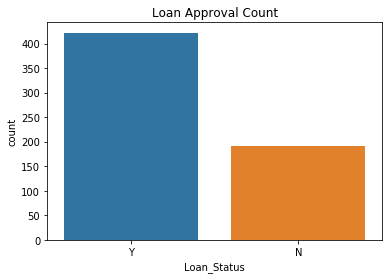

In [25]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Count")
plt.show()

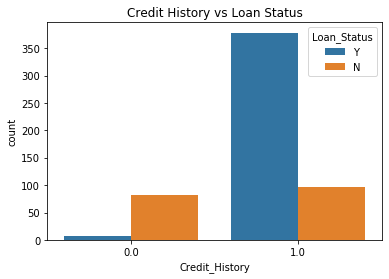

In [26]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

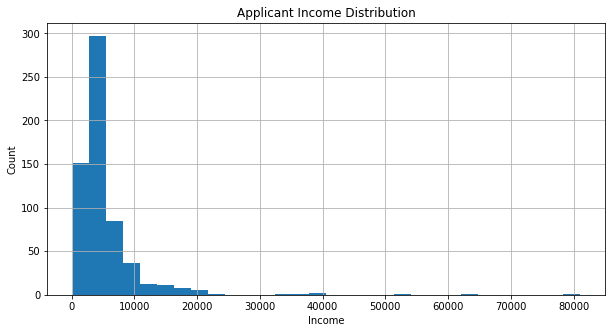

In [29]:
plt.figure(figsize=(10,5))
df['ApplicantIncome'].hist(bins=30)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

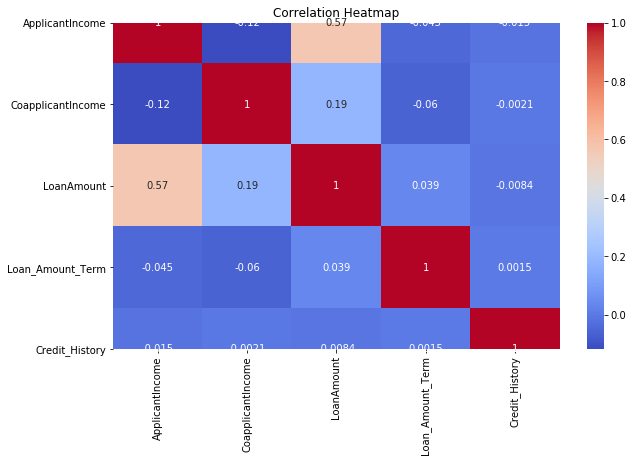

In [28]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [30]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [31]:
# Fill text columns with most common value (mode)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# Fill LoanAmount with median (because it has outliers)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [32]:
# New Feature 1 — Total household income
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# New Feature 2 — EMI (monthly payment estimate)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

# New Feature 3 — Income to Loan ratio
df['IncomeToLoan'] = df['TotalIncome'] / df['LoanAmount']

print("New columns added!")
print(df[['TotalIncome', 'EMI', 'IncomeToLoan']].head())

New columns added!
   TotalIncome       EMI  IncomeToLoan
0       5849.0  0.355556     45.695312
1       6091.0  0.355556     47.585938
2       3000.0  0.183333     45.454545
3       4941.0  0.333333     41.175000
4       6000.0  0.391667     42.553191


In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols_to_encode = ['Gender', 'Married', 'Dependents',
                  'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cols_to_encode:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
print(df.head())

Encoding done!
    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  TotalIncome       EMI  \
0             1.0              2            1       5849.0  0.355

In [34]:
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)

Shape: (614, 16)

Missing values: 0

Data types:
Loan_ID               object
Gender                 int32
Married                int32
Dependents             int32
Education              int32
Self_Employed          int32
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int32
Loan_Status            int32
TotalIncome          float64
EMI                  float64
IncomeToLoan         float64
dtype: object


In [35]:
df.to_csv('data/clean_train.csv', index=False)
print("Clean data saved!")


Clean data saved!


In [36]:
# Drop columns model doesn't need
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (614, 14)
Target shape: (614,)

Feature columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome', 'EMI', 'IncomeToLoan']


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (491, 14)
Testing size: (123, 14)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

print("All models imported!")

All models imported!


In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False,
                              eval_metric='logloss',
                              random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    results[name] = {"Accuracy": round(acc*100, 2), "ROC-AUC": round(auc, 3)}
    print(f"{name} → Accuracy: {round(acc*100,2)}%")

print("\nDone training all models!")

Logistic Regression → Accuracy: 78.86%
Decision Tree → Accuracy: 66.67%
Random Forest → Accuracy: 79.67%
Gradient Boosting → Accuracy: 80.49%
XGBoost → Accuracy: 76.42%

Done training all models!


In [40]:
import pandas as pd

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print(results_df)

                     Accuracy  ROC-AUC
Gradient Boosting       80.49    0.748
Random Forest           79.67    0.731
Logistic Regression     78.86    0.703
XGBoost                 76.42    0.706
Decision Tree           66.67    0.636


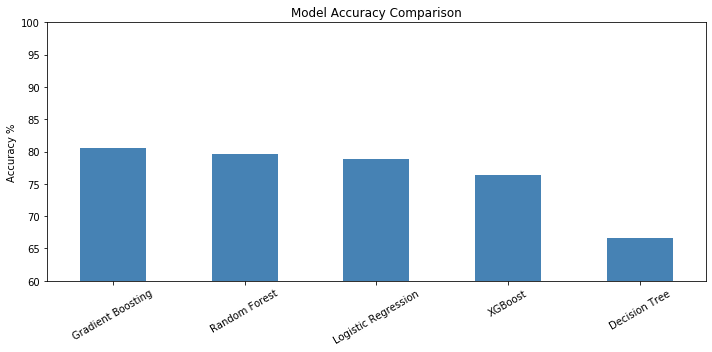

In [41]:
results_df['Accuracy'].plot(kind='bar', color='steelblue',
                             figsize=(10,5), rot=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy %")
plt.ylim(60, 100)
plt.tight_layout()
plt.show()

In [42]:
import pickle

# Save the best model (Random Forest or XGBoost — whichever scores highest)
best_model = models["Random Forest"]
pickle.dump(best_model, open('data/model.pkl', 'wb'))
print("Model saved!")

Model saved!


In [43]:
best_model = models["Gradient Boosting"]
pickle.dump(best_model, open('data/model.pkl', 'wb'))
print("Best model saved → Gradient Boosting 80.49%")

Best model saved → Gradient Boosting 80.49%


In [44]:
import shap
import warnings
warnings.filterwarnings('ignore')

print("SHAP imported!")

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


SHAP imported!


In [45]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated!
Shape of SHAP values: (123, 14)


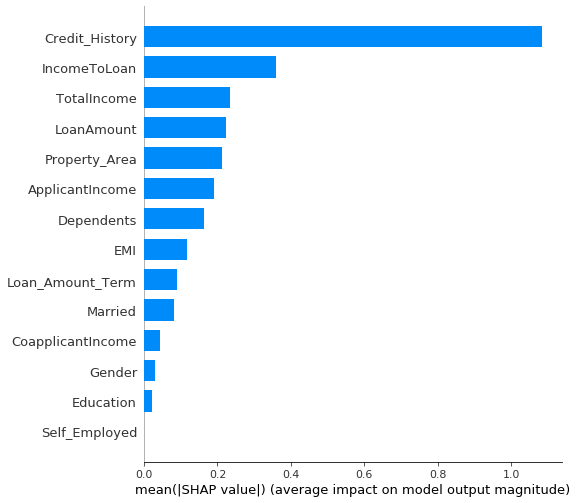

In [46]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")

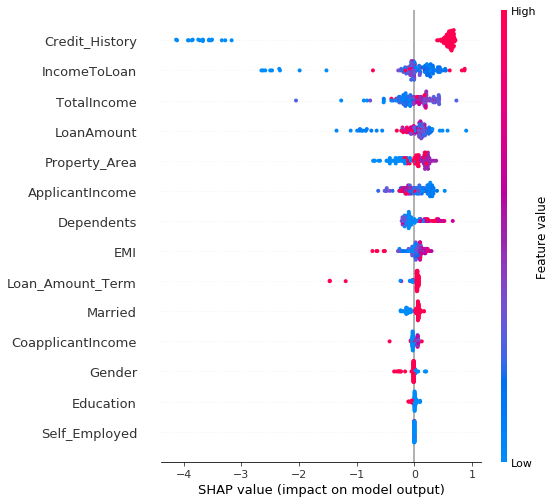

In [47]:
shap.summary_plot(shap_values, X_test)

In [48]:
# Pick first person in test set
person_index = 0

print("Actual result:", "Approved" if y_test.iloc[person_index] == 1 else "Rejected")
print("Model predicted:", "Approved" if best_model.predict(X_test.iloc[[person_index]])[0] == 1 else "Rejected")
print("\nTop factors for this person:")

# Get SHAP values for this person
person_shap = shap_values[person_index]
feature_names = X_test.columns

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Value': person_shap
}).sort_values('SHAP Value', ascending=False)

print(shap_df)

Actual result: Approved
Model predicted: Approved

Top factors for this person:
              Feature  SHAP Value
9      Credit_History    0.633933
13       IncomeToLoan    0.189359
10      Property_Area    0.185707
12                EMI    0.097029
1             Married    0.090753
11        TotalIncome    0.074356
8    Loan_Amount_Term    0.045037
3           Education    0.016065
4       Self_Employed    0.000000
0              Gender   -0.013088
6   CoapplicantIncome   -0.028459
7          LoanAmount   -0.131386
2          Dependents   -0.137893
5     ApplicantIncome   -0.194299


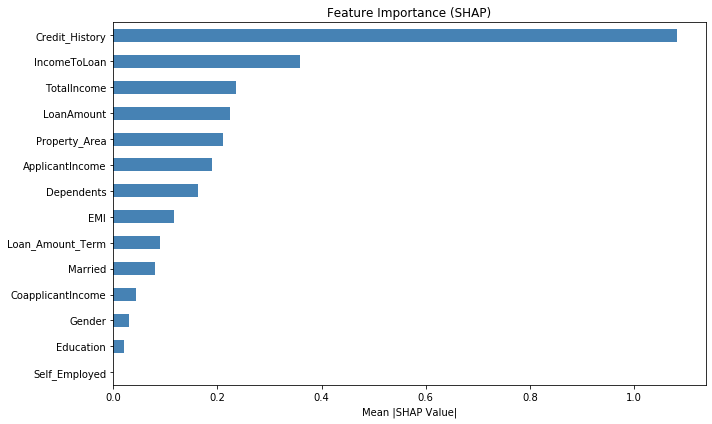

In [49]:
# Clean feature importance chart
feat_imp = pd.Series(
    abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title("Feature Importance (SHAP)")
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()